In [64]:
!pip install -q pandas numpy matplotlib seaborn statsmodels
!pip install -q statsforecast mlforecast neuralforecast lightgbm xgboost

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [66]:
url = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"

raw = pd.read_csv(url, parse_dates=["Date"])

raw.head()

,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,NaN,NaN,NaN
1,2006-01-02,1380.521,NaN,NaN,NaN
2,2006-01-03,1442.533,NaN,NaN,NaN
3,2006-01-04,1457.217,NaN,NaN,NaN
4,2006-01-05,1477.131,NaN,NaN,NaN


In [67]:
df = raw[["Date", "Consumption"]].copy()

df = df.rename(columns={
    "Date": "ds",
    "Consumption": "y"
})

df["unique_id"] = "DE_consumption"

df = df[["unique_id", "ds", "y"]]
df = df.sort_values("ds").reset_index(drop=True)

print("Размер данных:", df.shape)
df.head()

Размер данных: (4383, 3)


,unique_id,ds,y
0,DE_consumption,2006-01-01,1069.184
1,DE_consumption,2006-01-02,1380.521
2,DE_consumption,2006-01-03,1442.533
3,DE_consumption,2006-01-04,1457.217
4,DE_consumption,2006-01-05,1477.131


In [68]:
print("Пропуски до обработки:")
print(df.isna().sum())

df["y"] = df["y"].interpolate(method="linear")

print("\nПропуски после обработки:")
print(df.isna().sum())

Пропуски до обработки:
unique_id    0
ds           0
y            0
dtype: int64

Пропуски после обработки:
unique_id    0
ds           0
y            0
dtype: int64


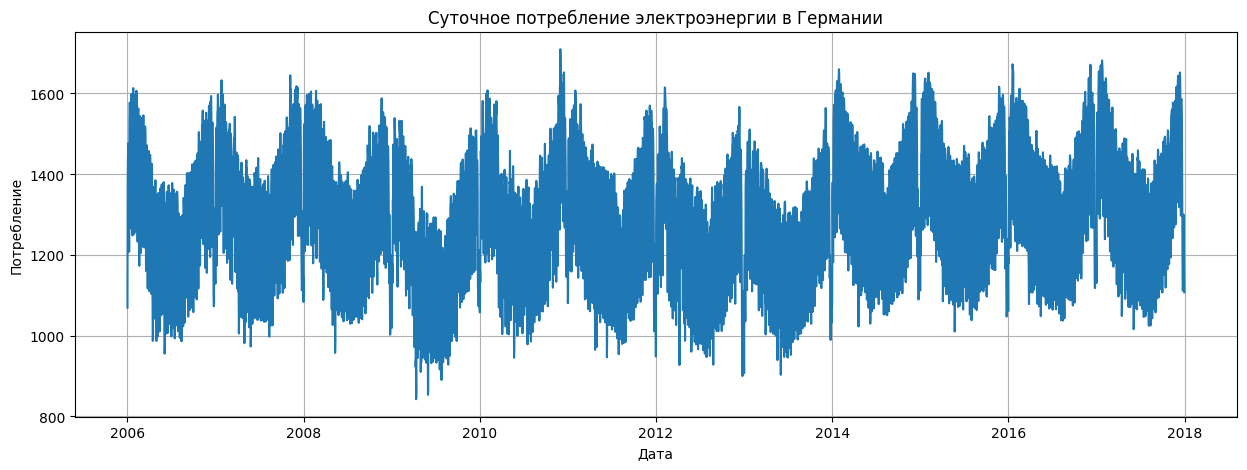

In [69]:
plt.figure(figsize=(15, 5))
plt.plot(df["ds"], df["y"])
plt.title("Суточное потребление электроэнергии в Германии")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.grid(True)
plt.show()

In [70]:
eda = df.copy()

eda["year"] = eda["ds"].dt.year
eda["month"] = eda["ds"].dt.month
eda["dayofweek"] = eda["ds"].dt.dayofweek
eda["day"] = eda["ds"].dt.day

eda.head()

,unique_id,ds,y,year,month,dayofweek,day
0,DE_consumption,2006-01-01,1069.184,2006,1,6,1
1,DE_consumption,2006-01-02,1380.521,2006,1,0,2
2,DE_consumption,2006-01-03,1442.533,2006,1,1,3
3,DE_consumption,2006-01-04,1457.217,2006,1,2,4
4,DE_consumption,2006-01-05,1477.131,2006,1,3,5


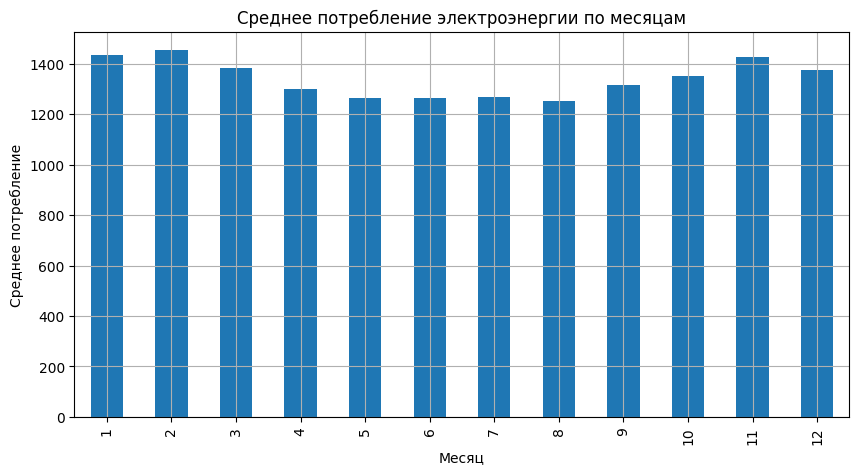

In [71]:
monthly = eda.groupby("month")["y"].mean()

plt.figure(figsize=(10, 5))
monthly.plot(kind="bar")
plt.title("Среднее потребление электроэнергии по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Среднее потребление")
plt.grid(True)
plt.show()

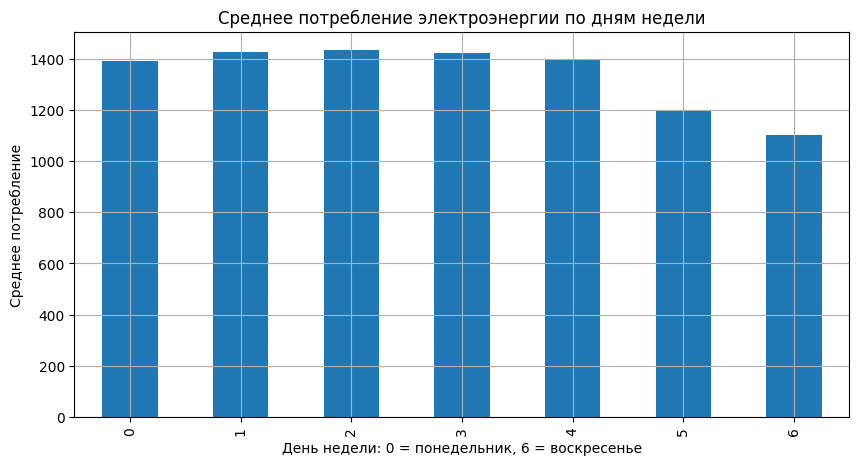

In [72]:
weekday = eda.groupby("dayofweek")["y"].mean()

plt.figure(figsize=(10, 5))
weekday.plot(kind="bar")
plt.title("Среднее потребление электроэнергии по дням недели")
plt.xlabel("День недели: 0 = понедельник, 6 = воскресенье")
plt.ylabel("Среднее потребление")
plt.grid(True)
plt.show()

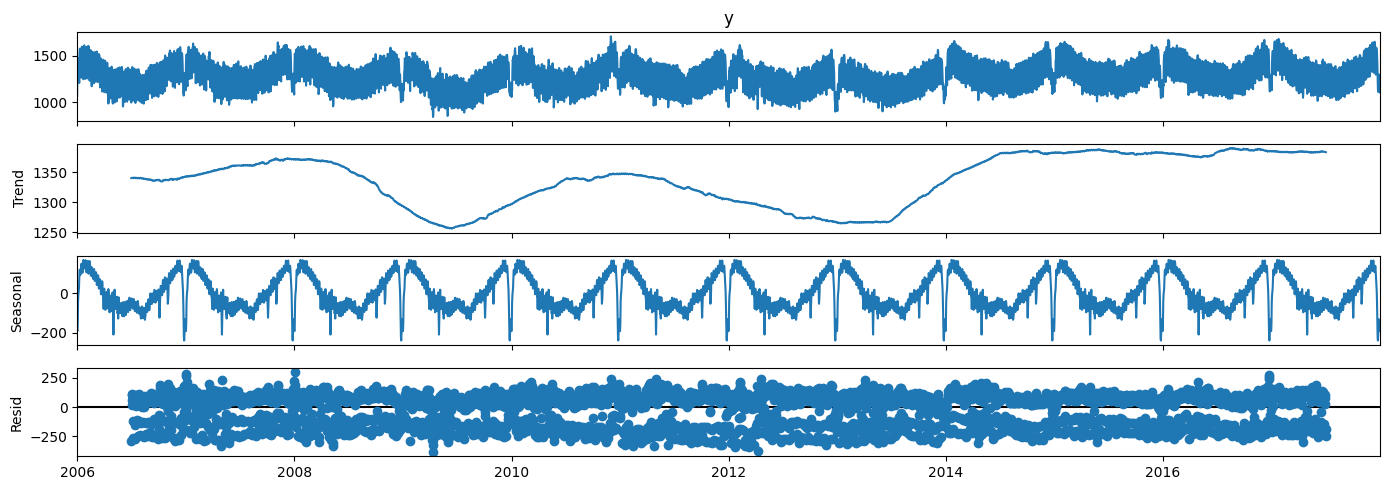

In [73]:
series = df.set_index("ds")["y"].asfreq("D")
series = series.interpolate()

decomposition = seasonal_decompose(series, model="additive", period=365)

decomposition.plot()
plt.show()

In [74]:
adf_result = adfuller(series.dropna())

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Ряд можно считать стационарным по ADF-тесту.")
else:
    print("Ряд нельзя считать стационарным по ADF-тесту.")

ADF statistic: -6.239148288864479
p-value: 4.7440549018425884e-08
Ряд можно считать стационарным по ADF-тесту.


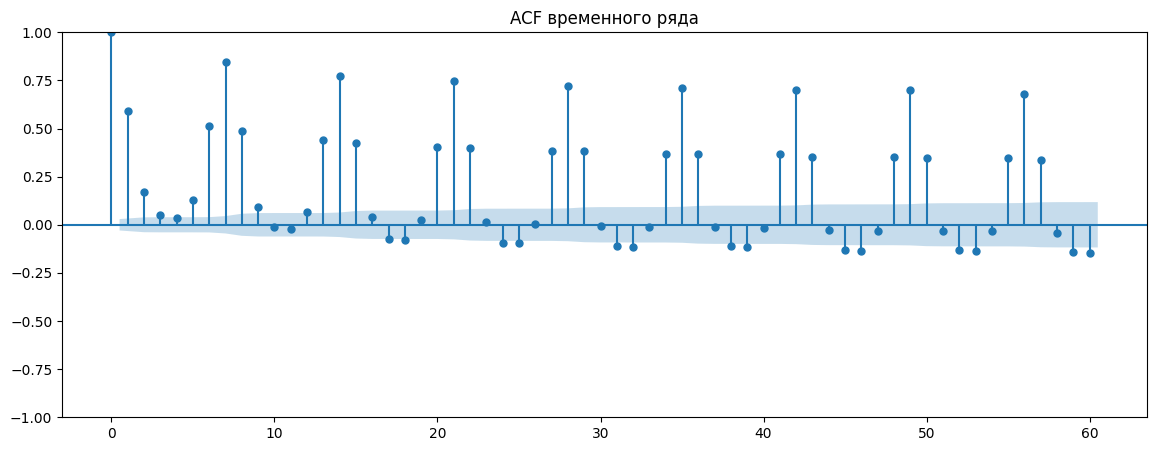

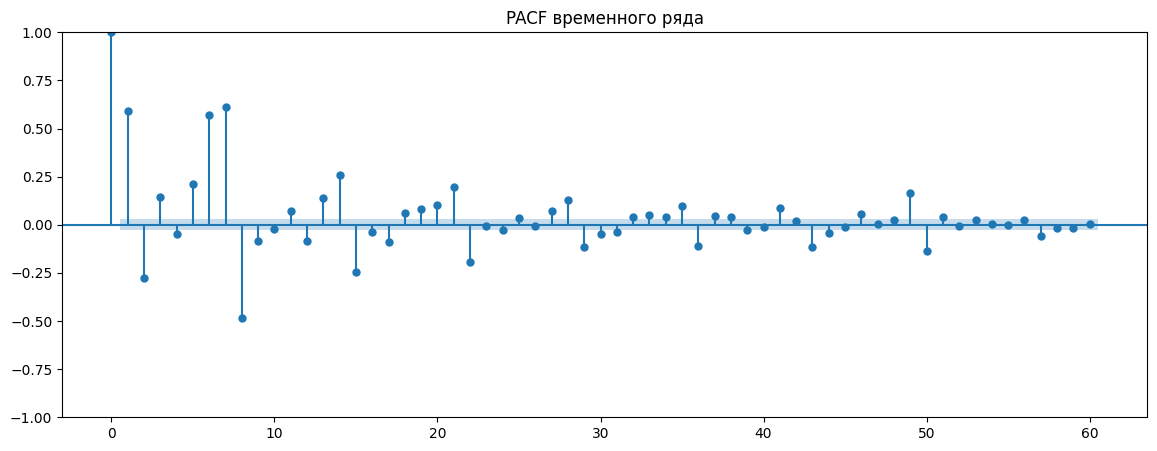

In [75]:
plot_acf(series.dropna(), lags=60)
plt.title("ACF временного ряда")
plt.show()

plot_pacf(series.dropna(), lags=60)
plt.title("PACF временного ряда")
plt.show()

In [76]:
df.to_csv("/content/ts_prepared.csv", index=False)

print("Файл создан:", os.path.exists("/content/ts_prepared.csv"))

Файл создан: True


In [77]:
h = 30  # горизонт прогноза: 30 дней

train = df.iloc[:-h].copy()
test = df.iloc[-h:].copy()

print("Train:", train["ds"].min(), "—", train["ds"].max(), train.shape)
print("Test:", test["ds"].min(), "—", test["ds"].max(), test.shape)

Train: 2006-01-01 00:00:00 — 2017-12-01 00:00:00 (4353, 3)
Test: 2017-12-02 00:00:00 — 2017-12-31 00:00:00 (30, 3)


In [78]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    HistoricAverage,
    RandomWalkWithDrift,
    AutoARIMA,
    AutoETS,
    AutoTheta
)

stat_models = [
    Naive(),
    SeasonalNaive(season_length=7),
    HistoricAverage(),
    RandomWalkWithDrift(),
    AutoARIMA(season_length=7),
    AutoETS(season_length=7),
    AutoTheta(season_length=7)
]

sf = StatsForecast(
    models=stat_models,
    freq="D",
    n_jobs=-1
)

stat_forecast = sf.forecast(df=train, h=h)

stat_forecast.head()

,unique_id,ds,Naive,SeasonalNaive,HistoricAverage,RWD,AutoARIMA,AutoETS,AutoTheta
0,DE_consumption,2017-12-02,1592.96187,1333.15585,1338.04228,1593.082223,1385.357762,1375.617427,1367.592669
1,DE_consumption,2017-12-03,1592.96187,1276.09818,1338.04228,1593.202577,1292.742679,1279.916524,1256.268798
2,DE_consumption,2017-12-04,1592.96187,1602.17797,1338.04228,1593.322930,1597.447366,1565.171303,1582.893339
3,DE_consumption,2017-12-05,1592.96187,1615.38061,1338.04228,1593.443283,1614.373874,1602.166137,1628.003741
4,DE_consumption,2017-12-06,1592.96187,1603.98435,1338.04228,1593.563637,1597.174601,1625.648803,1634.003566


In [79]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

def evaluate_forecast(test, forecast):
    result = []
    y_true = test["y"].values

    model_cols = [c for c in forecast.columns if c not in ["unique_id", "ds"]]

    for model in model_cols:
        y_pred = forecast[model].values

        result.append({
            "model": model,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred)
        })

    return pd.DataFrame(result).sort_values("sMAPE")

stat_metrics = evaluate_forecast(test, stat_forecast)

stat_metrics

,model,MAE,RMSE,sMAPE
4,AutoARIMA,109.331197,173.694739,7.821677
5,AutoETS,110.172334,172.661278,7.882930
6,AutoTheta,110.250613,175.705016,7.900004
1,SeasonalNaive,111.014721,174.370901,7.950544
2,HistoricAverage,177.504579,206.592918,12.586605
0,Naive,186.599312,245.911891,13.046412
3,RWD,187.895117,247.654774,13.126353


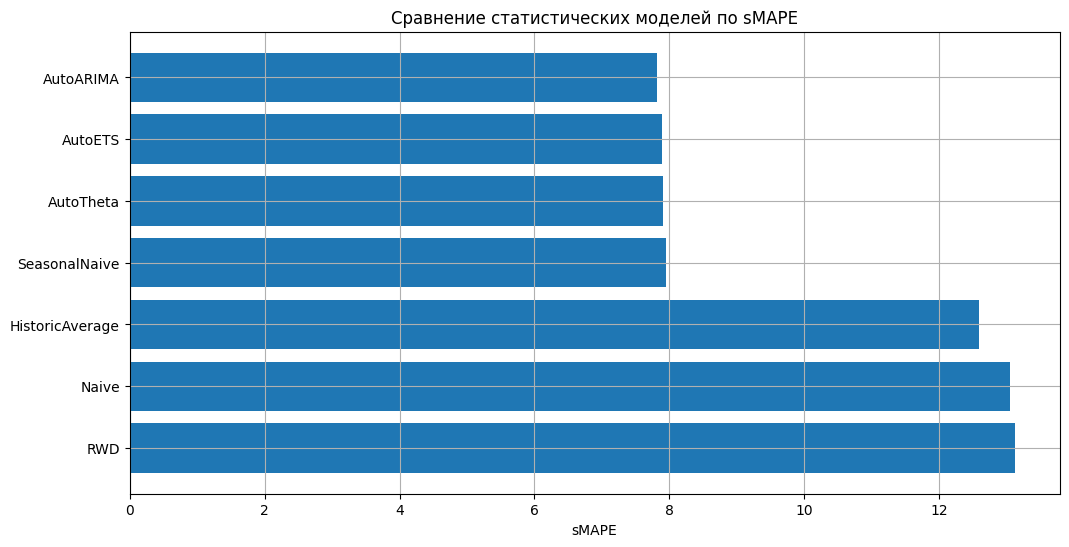

In [80]:
plt.figure(figsize=(12, 6))
plt.barh(stat_metrics["model"], stat_metrics["sMAPE"])
plt.xlabel("sMAPE")
plt.title("Сравнение статистических моделей по sMAPE")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

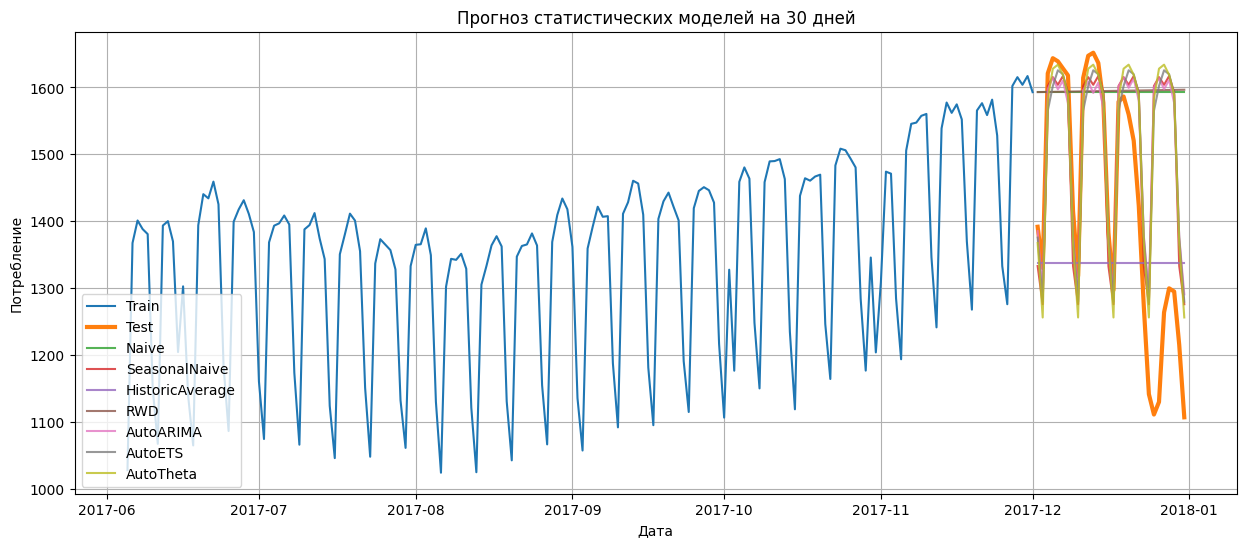

In [81]:
plt.figure(figsize=(15, 6))

plt.plot(train["ds"].iloc[-180:], train["y"].iloc[-180:], label="Train")
plt.plot(test["ds"], test["y"], label="Test", linewidth=3)

model_cols = [c for c in stat_forecast.columns if c not in ["unique_id", "ds"]]

for model in model_cols:
    plt.plot(stat_forecast["ds"], stat_forecast[model], label=model, alpha=0.8)

plt.title("Прогноз статистических моделей на 30 дней")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.legend()
plt.grid(True)
plt.show()

Вывод по статистическим моделям

На горизонте прогнозирования 30 дней были сравнены статистические модели Naive, SeasonalNaive, HistoricAverage, RandomWalkWithDrift, AutoARIMA, AutoETS и AutoTheta.
Лучший результат по метрике sMAPE показала модель AutoARIMA: sMAPE = 7.82%, MAE = 109.33, RMSE = 173.69. Близкие результаты также показали AutoETS и AutoTheta, что говорит о наличии выраженной сезонной и авторегрессионной структуры временного ряда.
Простые бейзлайн-модели Naive, HistoricAverage и RandomWalkWithDrift показали более высокую ошибку. Это подтверждает, что для данного временного ряда использование моделей, учитывающих сезонность и структуру зависимости от прошлых значений, является более обоснованным.

In [82]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from lightgbm import LGBMRegressor

ml_models = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=200, random_state=42),
    ExtraTreesRegressor(n_estimators=200, random_state=42),
    LGBMRegressor(random_state=42)
]

mlf = MLForecast(
    models=ml_models,
    freq="D",
    lags=[1, 2, 3, 7, 14, 30],
    lag_transforms={
        1: [RollingMean(window_size=7), RollingMean(window_size=30)],
        7: [RollingMean(window_size=4), RollingStd(window_size=4)]
    },
    date_features=["dayofweek", "month"]
)

mlf.fit(train)

ml_forecast = mlf.predict(h=h)

ml_forecast.head()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2570
[LightGBM] [Info] Number of data points in the train set: 4323, number of used features: 12
[LightGBM] [Info] Start training from score 1337.212230


,unique_id,ds,LinearRegression,RandomForestRegressor,ExtraTreesRegressor,LGBMRegressor
0,DE_consumption,2017-12-02,1408.234563,1376.085590,1369.321355,1378.437806
1,DE_consumption,2017-12-03,1266.918424,1280.652413,1279.597130,1281.498067
2,DE_consumption,2017-12-04,1556.218961,1591.594114,1595.940399,1556.408648
3,DE_consumption,2017-12-05,1585.036246,1613.501251,1612.469551,1583.527409
4,DE_consumption,2017-12-06,1571.638027,1602.800871,1606.768161,1581.654458


In [83]:
ml_metrics = evaluate_forecast(test, ml_forecast)

ml_metrics

,model,MAE,RMSE,sMAPE
1,RandomForestRegressor,63.252180,87.614502,4.688317
2,ExtraTreesRegressor,67.691542,95.200162,5.046906
3,LGBMRegressor,70.435467,85.566519,5.095201
0,LinearRegression,99.544322,131.420053,7.123632


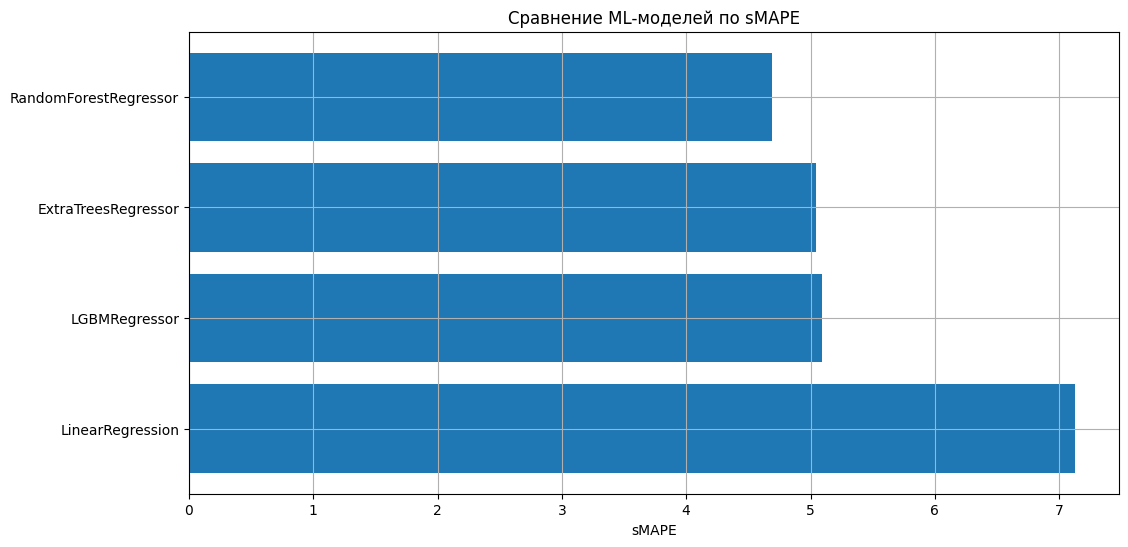

In [84]:
plt.figure(figsize=(12, 6))
plt.barh(ml_metrics["model"], ml_metrics["sMAPE"])
plt.xlabel("sMAPE")
plt.title("Сравнение ML-моделей по sMAPE")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

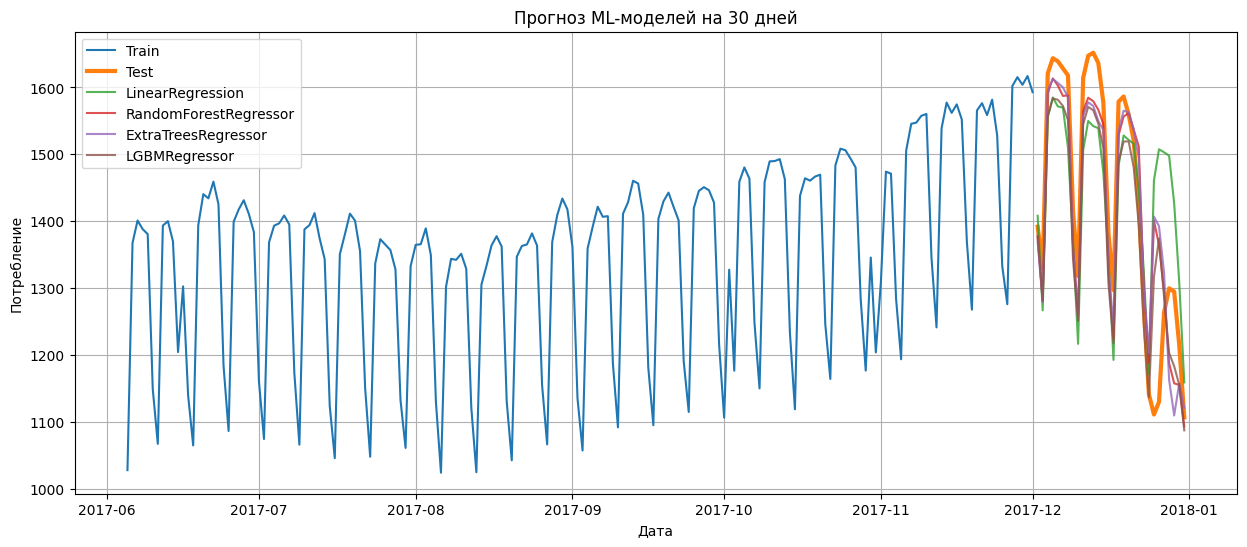

In [85]:
plt.figure(figsize=(15, 6))

plt.plot(train["ds"].iloc[-180:], train["y"].iloc[-180:], label="Train")
plt.plot(test["ds"], test["y"], label="Test", linewidth=3)

model_cols = [c for c in ml_forecast.columns if c not in ["unique_id", "ds"]]

for model in model_cols:
    plt.plot(ml_forecast["ds"], ml_forecast[model], label=model, alpha=0.8)

plt.title("Прогноз ML-моделей на 30 дней")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.legend()
plt.grid(True)
plt.show()

ML-модели прогнозирования временного ряда

На данном этапе были протестированы модели машинного обучения: LinearRegression, RandomForestRegressor, ExtraTreesRegressor и LGBMRegressor.
Для моделей были сформированы признаки временного ряда: лаги 1, 2, 3, 7, 14 и 30 дней, скользящие средние, скользящее стандартное отклонение, а также календарные признаки дня недели и месяца.
Лучший результат по метрике sMAPE показала модель RandomForestRegressor: sMAPE = 4.69%, MAE = 63.25, RMSE = 87.61. Это лучше результата лучшей статистической модели AutoARIMA, у которой sMAPE = 7.82%.
Полученный результат показывает, что ML-модели с лаговыми и календарными признаками лучше учитывают локальные закономерности временного ряда и дают более точный прогноз на выбранном горизонте 30 дней.

In [86]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, LSTM

dl_models = [
    NBEATS(
        h=h,
        input_size=90,
        max_steps=50,
        random_seed=42
    ),
    NHITS(
        h=h,
        input_size=90,
        max_steps=50,
        random_seed=42
    ),
    LSTM(
        h=h,
        input_size=90,
        max_steps=50,
        encoder_hidden_size=32,
        decoder_hidden_size=32,
        random_seed=42
    )
]

nf = NeuralForecast(
    models=dl_models,
    freq="D"
)

nf.fit(df=train)

dl_forecast = nf.predict()

dl_forecast.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
7.3 K     Non-trainable params
2.6 M     Total params
10.541    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.491    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,NBEATS,NHITS,LSTM
0,DE_consumption,2017-12-02,1376.141113,1408.565186,1403.295166
1,DE_consumption,2017-12-03,1246.783936,1383.795532,1387.513062
2,DE_consumption,2017-12-04,1559.181030,1458.241211,1387.045044
3,DE_consumption,2017-12-05,1577.845581,1557.267822,1399.627930
4,DE_consumption,2017-12-06,1597.468872,1639.907959,1392.901855


In [87]:
dl_metrics = evaluate_forecast(test, dl_forecast)

dl_metrics

,model,MAE,RMSE,sMAPE
0,NBEATS,110.106927,164.917906,7.890354
1,NHITS,134.736468,181.147271,9.587468
2,LSTM,167.198628,188.861839,11.837720


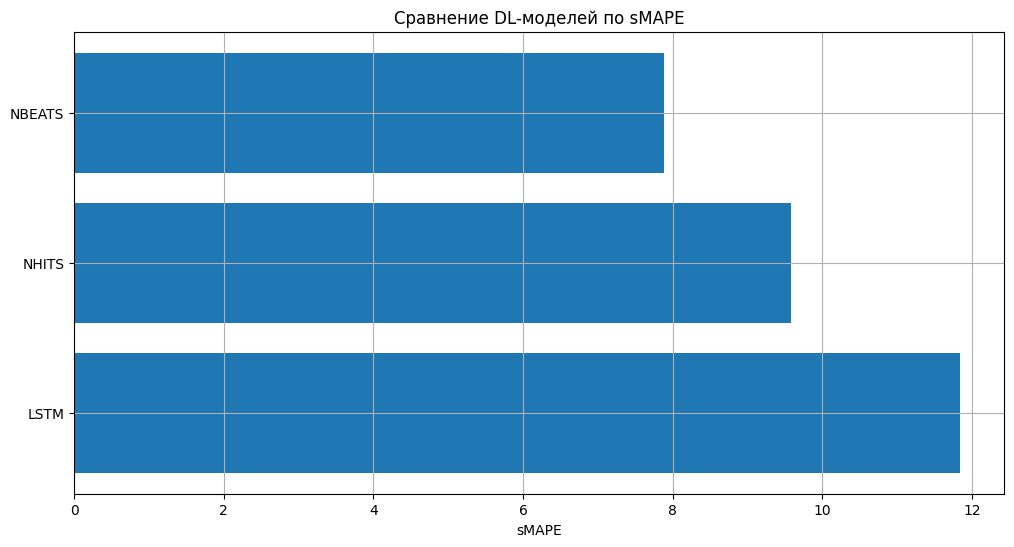

In [88]:
plt.figure(figsize=(12, 6))
plt.barh(dl_metrics["model"], dl_metrics["sMAPE"])
plt.xlabel("sMAPE")
plt.title("Сравнение DL-моделей по sMAPE")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

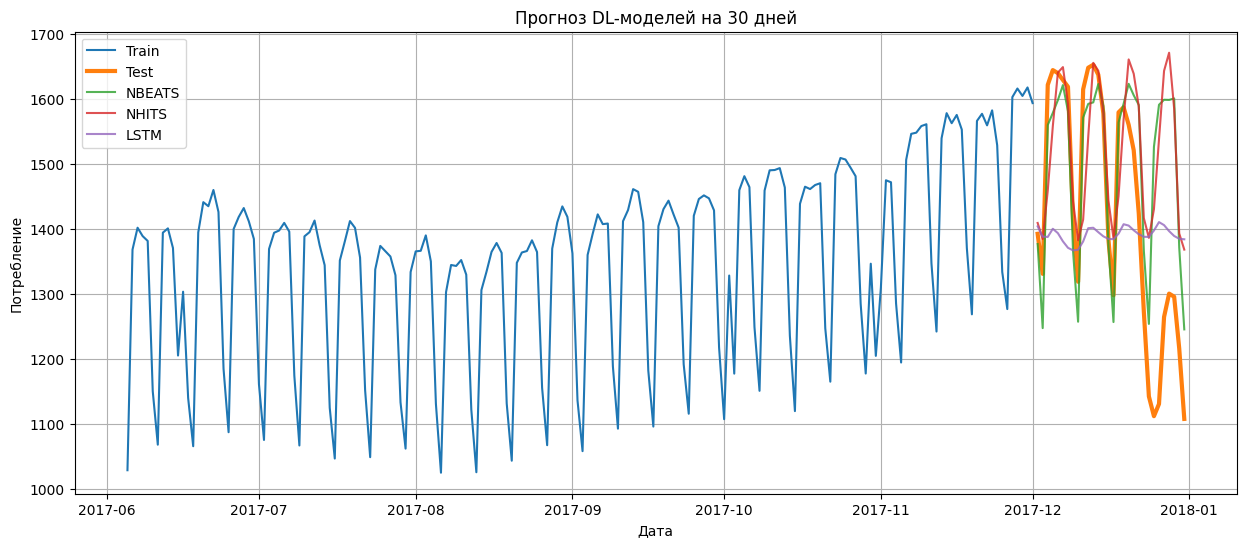

In [89]:
plt.figure(figsize=(15, 6))

plt.plot(train["ds"].iloc[-180:], train["y"].iloc[-180:], label="Train")
plt.plot(test["ds"], test["y"], label="Test", linewidth=3)

model_cols = [c for c in dl_forecast.columns if c not in ["unique_id", "ds"]]

for model in model_cols:
    plt.plot(dl_forecast["ds"], dl_forecast[model], label=model, alpha=0.8)

plt.title("Прогноз DL-моделей на 30 дней")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.legend()
plt.grid(True)
plt.show()

Вывод по DL-моделям

На данном этапе были протестированы модели глубокого обучения NBEATS, NHITS и LSTM. Горизонт прогнозирования составил 30 дней.
Лучший результат среди DL-моделей показала модель NBEATS: sMAPE = 7.89%, MAE = 110.11, RMSE = 164.92. Модели NHITS и LSTM показали более высокую ошибку на тестовом интервале.
Несмотря на использование нейросетевых методов, лучшая DL-модель уступила ML-модели RandomForestRegressor. Это может быть связано с тем, что для данного набора данных и короткого горизонта прогнозирования модели машинного обучения с лаговыми, скользящими и календарными признаками оказались более устойчивыми и точными.


In [90]:
all_metrics = pd.concat(
    [
        stat_metrics.assign(group="Statistical"),
        ml_metrics.assign(group="ML"),
        dl_metrics.assign(group="DL")
    ],
    ignore_index=True
)

all_metrics = all_metrics.sort_values("sMAPE").reset_index(drop=True)

all_metrics

,model,MAE,RMSE,sMAPE,group
0,RandomForestRegressor,63.252180,87.614502,4.688317,ML
1,ExtraTreesRegressor,67.691542,95.200162,5.046906,ML
2,LGBMRegressor,70.435467,85.566519,5.095201,ML
3,LinearRegression,99.544322,131.420053,7.123632,ML
4,AutoARIMA,109.331197,173.694739,7.821677,Statistical
5,AutoETS,110.172334,172.661278,7.882930,Statistical
6,NBEATS,110.106927,164.917906,7.890354,DL
7,AutoTheta,110.250613,175.705016,7.900004,Statistical
8,SeasonalNaive,111.014721,174.370901,7.950544,Statistical
9,NHITS,134.736468,181.147271,9.587468,DL


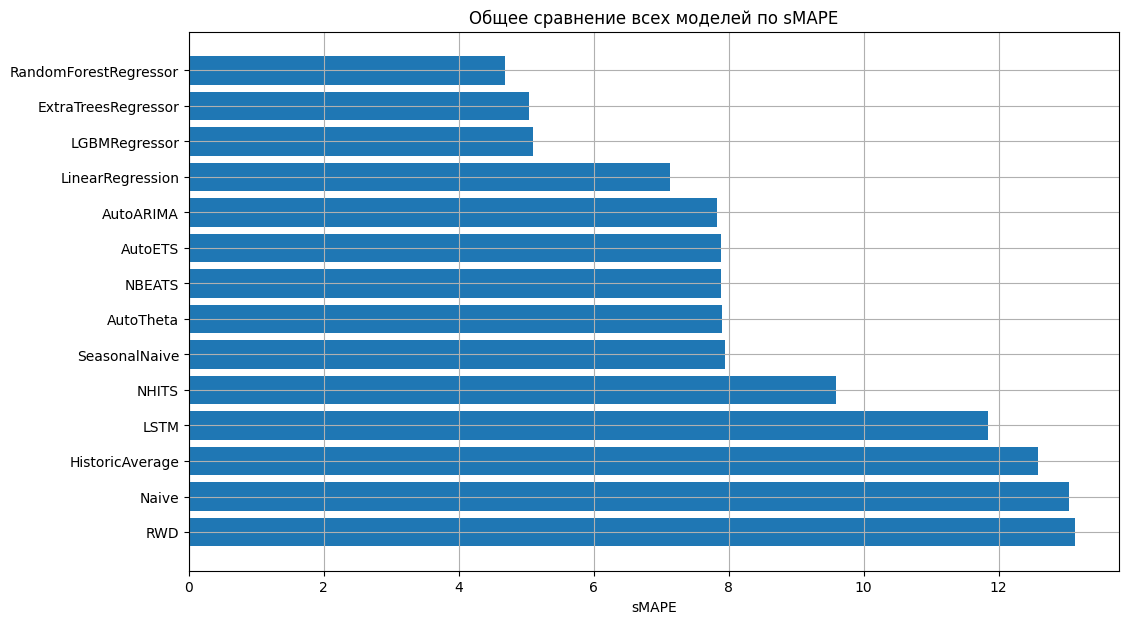

In [91]:
plt.figure(figsize=(12, 7))
plt.barh(all_metrics["model"], all_metrics["sMAPE"])
plt.xlabel("sMAPE")
plt.title("Общее сравнение всех моделей по sMAPE")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [92]:
best_model = all_metrics.iloc[0]

print("Лучшая модель:")
print(best_model)

Лучшая модель:
model    RandomForestRegressor
MAE                   63.25218
RMSE                 87.614502
sMAPE                 4.688317
group                       ML
Name: 0, dtype: object


Итоговое сравнение моделей

В работе были протестированы статистические модели, модели машинного обучения и модели глубокого обучения.
По итогам общего сравнения лучшей моделью стала RandomForestRegressor. Она показала минимальное значение ошибки: sMAPE = 4.69%, MAE = 63.25, RMSE = 87.61.
Среди статистических моделей лучший результат показала AutoARIMA, среди моделей глубокого обучения — NBEATS. Однако RandomForestRegressor оказался точнее обеих групп моделей.
Таким образом, для выбранного временного ряда и горизонта прогнозирования 30 дней наиболее эффективным оказался подход машинного обучения с использованием лагов, скользящих статистик и календарных признаков.

In [93]:
best_mlf = MLForecast(
    models=[
        RandomForestRegressor(n_estimators=200, random_state=42)
    ],
    freq="D",
    lags=[1, 2, 3, 7, 14, 30],
    lag_transforms={
        1: [RollingMean(window_size=7), RollingMean(window_size=30)],
        7: [RollingMean(window_size=4), RollingStd(window_size=4)]
    },
    date_features=["dayofweek", "month"]
)

cv_ml = best_mlf.cross_validation(
    df=df,
    h=30,
    n_windows=5,
    step_size=30
)

cv_ml.head()

,unique_id,ds,cutoff,y,RandomForestRegressor
0,DE_consumption,2017-08-04,2017-08-03,1349.423,1369.438020
1,DE_consumption,2017-08-05,2017-08-03,1130.134,1156.274405
2,DE_consumption,2017-08-06,2017-08-03,1024.324,1058.423220
3,DE_consumption,2017-08-07,2017-08-03,1302.062,1345.462935
4,DE_consumption,2017-08-08,2017-08-03,1343.899,1367.731170


In [94]:
def evaluate_cv(cv_df):
    result = []
    y_true = cv_df["y"].values

    model_cols = [c for c in cv_df.columns if c not in ["unique_id", "ds", "cutoff", "y"]]

    for model in model_cols:
        y_pred = cv_df[model].values

        result.append({
            "model": model,
            "MAE": mae(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred)
        })

    return pd.DataFrame(result).sort_values("sMAPE").reset_index(drop=True)

In [95]:
cv_ml_metrics = evaluate_cv(cv_ml)

cv_ml_metrics

,model,MAE,RMSE,sMAPE
0,RandomForestRegressor,96.075002,133.634518,7.12372


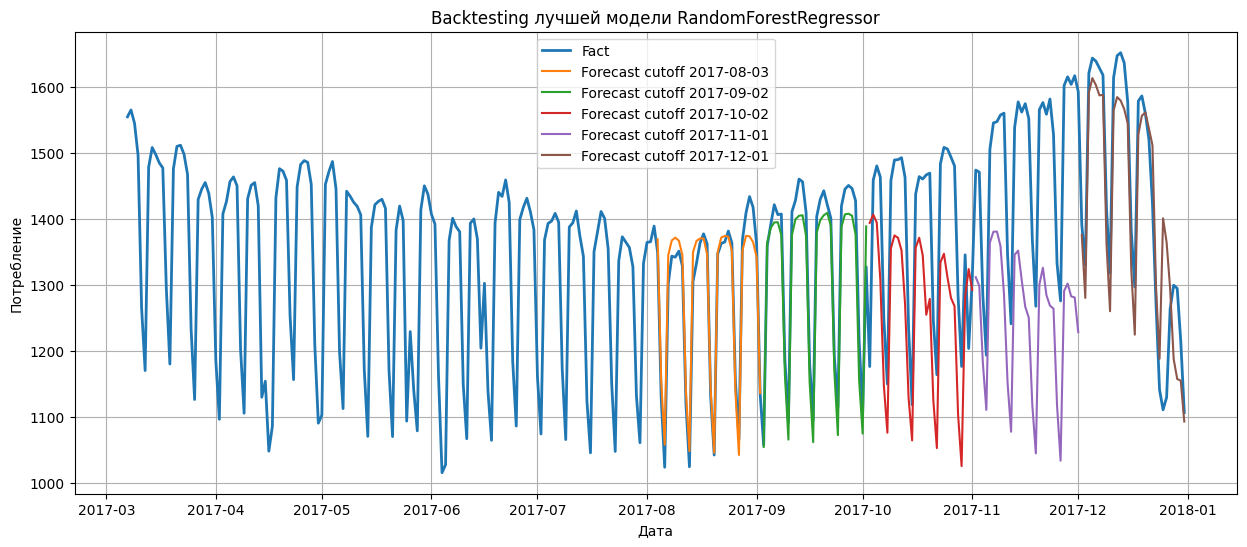

In [96]:
plt.figure(figsize=(15, 6))

plt.plot(df["ds"].iloc[-300:], df["y"].iloc[-300:], label="Fact", linewidth=2)

for cutoff in cv_ml["cutoff"].unique():
    temp = cv_ml[cv_ml["cutoff"] == cutoff]
    plt.plot(temp["ds"], temp["RandomForestRegressor"], label=f"Forecast cutoff {cutoff.date()}")

plt.title("Backtesting лучшей модели RandomForestRegressor")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.legend()
plt.grid(True)
plt.show()

Backtesting лучшей модели

Для проверки устойчивости лучшей модели был проведён backtesting с 5 окнами прогнозирования и горизонтом 30 дней. В качестве модели использовалась RandomForestRegressor, которая ранее показала лучший результат при сравнении всех моделей.
По результатам backtesting модель показала sMAPE = 7.12%, MAE = 96.08 и RMSE = 133.63. Ошибка оказалась выше, чем на одном тестовом интервале, однако результат остаётся сопоставимым с качеством лучших статистических и DL-моделей.
Backtesting показывает, что модель RandomForestRegressor в целом сохраняет устойчивое качество прогноза на разных временных окнах, хотя точность зависит от конкретного периода прогнозирования.

In [97]:
residuals = cv_ml["y"] - cv_ml["RandomForestRegressor"]

q_025 = residuals.quantile(0.025)
q_975 = residuals.quantile(0.975)

q_10 = residuals.quantile(0.10)
q_90 = residuals.quantile(0.90)

rf_interval_forecast = ml_forecast[["unique_id", "ds", "RandomForestRegressor"]].copy()

rf_interval_forecast["lower_95"] = rf_interval_forecast["RandomForestRegressor"] + q_025
rf_interval_forecast["upper_95"] = rf_interval_forecast["RandomForestRegressor"] + q_975

rf_interval_forecast["lower_80"] = rf_interval_forecast["RandomForestRegressor"] + q_10
rf_interval_forecast["upper_80"] = rf_interval_forecast["RandomForestRegressor"] + q_90

rf_interval_forecast.head()

,unique_id,ds,RandomForestRegressor,lower_95,upper_95,lower_80,upper_80
0,DE_consumption,2017-12-02,1376.085590,1278.804189,1688.896631,1352.138688,1618.802107
1,DE_consumption,2017-12-03,1280.652413,1183.371012,1593.463453,1256.705510,1523.368930
2,DE_consumption,2017-12-04,1591.594114,1494.312714,1904.405155,1567.647212,1834.310631
3,DE_consumption,2017-12-05,1613.501251,1516.219850,1926.312291,1589.554348,1856.217768
4,DE_consumption,2017-12-06,1602.800871,1505.519470,1915.611911,1578.853968,1845.517388


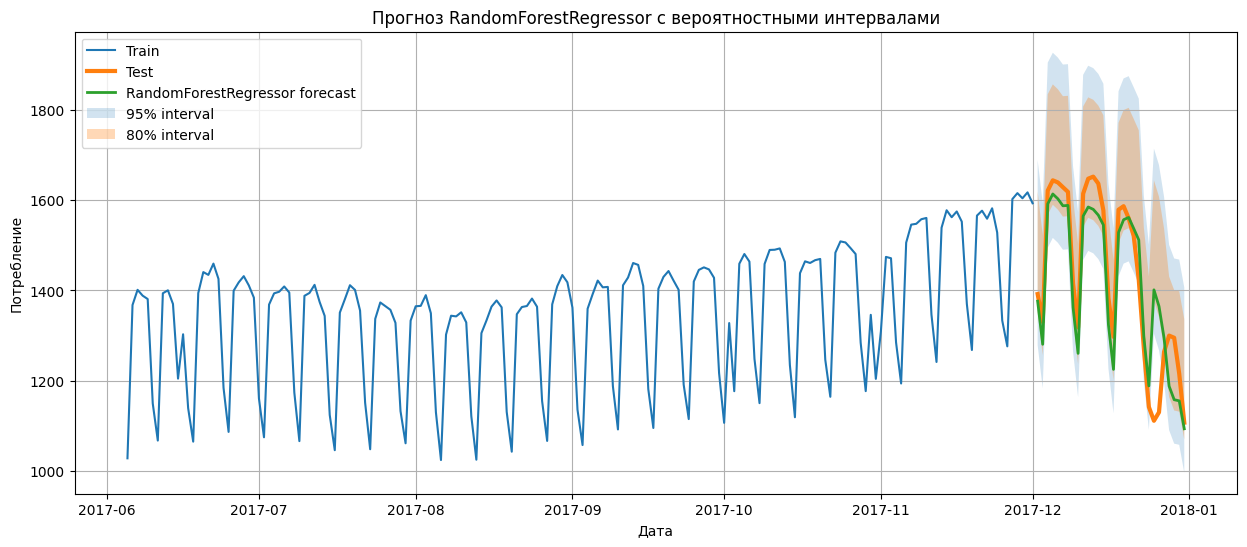

In [98]:
plt.figure(figsize=(15, 6))

plt.plot(train["ds"].iloc[-180:], train["y"].iloc[-180:], label="Train")
plt.plot(test["ds"], test["y"], label="Test", linewidth=3)
plt.plot(
    rf_interval_forecast["ds"],
    rf_interval_forecast["RandomForestRegressor"],
    label="RandomForestRegressor forecast",
    linewidth=2
)

plt.fill_between(
    rf_interval_forecast["ds"],
    rf_interval_forecast["lower_95"],
    rf_interval_forecast["upper_95"],
    alpha=0.2,
    label="95% interval"
)

plt.fill_between(
    rf_interval_forecast["ds"],
    rf_interval_forecast["lower_80"],
    rf_interval_forecast["upper_80"],
    alpha=0.3,
    label="80% interval"
)

plt.title("Прогноз RandomForestRegressor с вероятностными интервалами")
plt.xlabel("Дата")
plt.ylabel("Потребление")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
interval_check = test[["ds", "y"]].merge(
    rf_interval_forecast,
    on="ds",
    how="left"
)

coverage_80 = (
    (interval_check["y"] >= interval_check["lower_80"]) &
    (interval_check["y"] <= interval_check["upper_80"])
).mean() * 100

coverage_95 = (
    (interval_check["y"] >= interval_check["lower_95"]) &
    (interval_check["y"] <= interval_check["upper_95"])
).mean() * 100

print("Покрытие 80% интервала:", round(coverage_80, 2), "%")
print("Покрытие 95% интервала:", round(coverage_95, 2), "%")

Покрытие 80% интервала: 80.0 %
Покрытие 95% интервала: 93.33 %


Вероятностный прогноз и интервалы

Для лучшей модели RandomForestRegressor были построены вероятностные интервалы прогноза. Интервалы были рассчитаны на основе распределения ошибок, полученных при backtesting.
Были построены 80% и 95% интервалы прогноза. Проверка покрытия показала, что 80% интервал покрывает 80.0% фактических значений, а 95% интервал покрывает 93.33% фактических значений.
Это означает, что построенные интервалы в целом адекватно отражают неопределённость прогноза. Небольшое отклонение 95% интервала от теоретического значения может быть связано с ограниченным размером тестового горизонта и изменчивостью временного ряда.

Общий вывод по работе

В рамках работы был проведён полный цикл анализа и прогнозирования временного ряда суточного потребления электроэнергии в Германии.
На первом этапе были загружены и подготовлены данные, выполнен разведочный анализ, построены графики временного ряда, изучена сезонность по месяцам и дням недели, проведена декомпозиция ряда, ADF-тест, а также анализ ACF и PACF.
Далее были протестированы статистические модели, модели машинного обучения и модели глубокого обучения. Среди статистических моделей лучший результат показала AutoARIMA, среди DL-моделей — NBEATS. Однако наилучшее качество среди всех моделей показала модель RandomForestRegressor с использованием лаговых, скользящих и календарных признаков.
Итоговое качество лучшей модели на тестовом горизонте 30 дней составило: sMAPE = 4.69%, MAE = 63.25, RMSE = 87.61. При backtesting модель показала sMAPE = 7.12%, что подтверждает её достаточно устойчивое качество на разных временных окнах.
Таким образом, для выбранного временного ряда наиболее эффективным оказался ML-подход, основанный на feature engineering временного ряда и использовании RandomForestRegressor.

In [100]:
all_metrics.to_csv("/content/all_model_metrics.csv", index=False)
cv_ml_metrics.to_csv("/content/backtesting_metrics.csv", index=False)
rf_interval_forecast.to_csv("/content/probabilistic_forecast.csv", index=False)

print("Итоговые таблицы сохранены")

Итоговые таблицы сохранены


In [101]:
train.to_csv("/content/train_sample.csv", index=False)
test.to_csv("/content/test_sample.csv", index=False)

all_metrics.to_csv("/content/all_model_metrics.csv", index=False)
cv_ml_metrics.to_csv("/content/backtesting_metrics.csv", index=False)
rf_interval_forecast.to_csv("/content/probabilistic_forecast.csv", index=False)

print("Все файлы для репозитория сохранены")

Все файлы для репозитория сохранены
